In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
PROJECT_ROOT = os.path.abspath("..")

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
IMAGE_DIR = os.path.join(DATA_DIR, "train-image", "image")
CSV_PATH = os.path.join(DATA_DIR, "train-metadata.csv")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

In [44]:
df = pd.read_csv(CSV_PATH)
# Ensure `target` values are strings for flow_from_dataframe with class_mode='binary'
df['target'] = df['target'].astype(str)

df = df.drop(columns=["Unnamed: 0"]) 

# Create filename column
df["filename"] = df["isic_id"] + ".jpg"

df.head()

,isic_id,patient_id,target,filename
0,ISIC_2637011,IP_7279968,0,ISIC_2637011.jpg
1,ISIC_0015719,IP_3075186,0,ISIC_0015719.jpg
2,ISIC_0052212,IP_2842074,0,ISIC_0052212.jpg
3,ISIC_0068279,IP_6890425,0,ISIC_0068279.jpg
4,ISIC_0074268,IP_8723313,0,ISIC_0074268.jpg


In [45]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=42
)

print("Train:", len(train_df), "Validation:", len(val_df))

Train: 26500 Validation: 6626


In [48]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="target",
    target_size=(256, 256),
    batch_size=32,
    class_mode="binary"
)

val_data = val_gen.flow_from_dataframe(
    val_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="target",
    target_size=(256, 256),
    batch_size=32,
    class_mode="binary"
)

Found 26500 validated image filenames belonging to 2 classes.
Found 6626 validated image filenames belonging to 2 classes.


In [49]:
model = Sequential([
    Conv2D(32, 3, activation="relu", input_shape = (256, 256, 3)),
    MaxPooling2D(),
    BatchNormalization(),
    Conv2D(64, 3, activation="relu"),
    MaxPooling2D(),
    BatchNormalization(),
    Conv2D(128, 3, activation="relu"),
    MaxPooling2D(),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,001 (56.61 MB)

 Trainable params: 14,839,553 (56.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [51]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "cnn_baseline.h5"),
        save_best_only=True
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1,
    callbacks=callbacks
)

829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9760 - loss: 1.1034

829/829 ━━━━━━━━━━━━━━━━━━━━ 1227s 1s/step - accuracy: 0.9760 - loss: 1.1031 - val_accuracy: 0.9796 - val_loss: 2.1695


Details (from the matrix):

- True Negatives (TN): 6490
- False Positives (FP): 19
- False Negatives (FN): 116
- True Positives (TP): 1
- Total = 6626

Key rates:

- Accuracy = (TN+TP)/Total = 6491/6626 ≈ 0.98
- Positive precision = TP/(TP+FP) = 1/20 = 0.05
- Positive recall = TP/(TP+FN) = 1/117 ≈ 0.01
- F1 (positive) ≈ 0.01 (very low)

Found 6626 validated image filenames belonging to 2 classes.


C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


208/208 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step
Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6509
           1       0.05      0.01      0.01       117

    accuracy                           0.98      6626
   macro avg       0.52      0.50      0.50      6626
weighted avg       0.97      0.98      0.97      6626



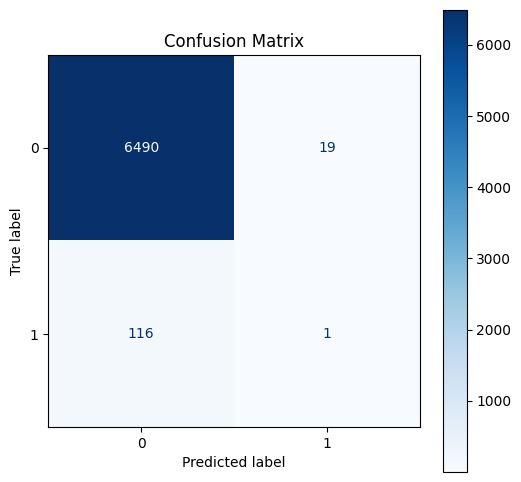

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

if 'model' in globals():
    m = model
elif os.path.exists(os.path.join(PROJECT_ROOT, 'models', 'best_model.h5')):
    m = load_model(os.path.join(PROJECT_ROOT, 'models', 'best_model.h5'))
elif os.path.exists('best_model.h5'):
    m = load_model('best_model.h5')
else:
    raise FileNotFoundError('No model found. Train a model or place `best_model.h5` in the models/ folder.')

pred_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    val_df,
    directory=IMAGE_DIR,
    x_col='filename',
    y_col='target',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

preds = m.predict(pred_gen, verbose=1)
y_pred = (preds.ravel() >= 0.5).astype(int)
y_true = pred_gen.classes

label_map = {v: k for k, v in pred_gen.class_indices.items()}
target_names = [label_map[i] for i in sorted(label_map.keys())]

print('Classification report:')
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix and plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()
